Para abrir o notebook no Google Colab, altere o domínio `github.com` para `githubtocolab.com`

<div class="alert alert-block alert-danger">
Para praticar programação, é importante que você erre, leia as mensagens de erro e tente corrigí-los.
    
Dessa forma, no Google Colab, é importante que você DESATIVE OS RECURSOS DE AUTOCOMPLETAR:

- Menu Ferramentas -> Configurações
- Na janela que é aberta:
  - Seção Editor -> Desativar "Mostrar sugestões de preenchimento de código com base no contexto"
  - Seção Assistência de IA -> Desabilitar itens

Na versão em inglês:

- Menu Tools -> Settings
- Na janela que é aberta:
  - Seção Editor -> Desativar "Show context-powered code completions"
  - Seção AI Assistance -> Desabilitar itens
</div>

# Introdução ao Python para processamento numérico e análise de dados

# Do NumPy ao PyTorch

No Google Colab, é necessário habilitar o suporte à GPU acessando "Change Runtime Type" e selecionando uma opção com GPU como, por exemplo, a "T4 GPU".

A seguir, serão apresentados os principais elementos do PyTorch, partindo de um exemplo de treinamento de um modelo com o LMS implementado com o NumPy. Serão abordados:

- Uso de tensores PyTorch;
- Uso do autograd;
- Blocos para função custo;
- Blocos para otimizadores;
- Uso de objetos representando modelos PyTorch;
- Uso de blocos PyTorch para a composição de modelos.

As mudanças no código serão indicadas por comentários.

## 1. Começando pelo NumPy

- Código para treinamento de um modelo com o LMS para identificação de sistemas:

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from scipy import signal
from torch import nn

In [2]:
N = 500
M = 3
sigmav2 = 0.01
eta = 0.1

x = np.random.randn(N, 1)
wo = np.array([[0.1, 0.2, 0.3]])
d = signal.lfilter(wo.squeeze(), 1, x.squeeze()) + np.sqrt(sigmav2) * np.random.randn(N)
d = d.reshape(-1, 1)

In [3]:
def lms(x, d, eta, M):
    N = len(x)
    xM = np.zeros((M, 1))
    wi = np.zeros((1, M))    
    y = np.zeros((N, 1))
    e = np.zeros((N, 1))
    w = np.zeros((N + 1, M))
    
    for i in range(N):
        xM = np.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        yi = wi @ xM
        ei = d[i] - yi
        wi = wi + eta/2 * 2 * ei * xM.T
        y[i] = yi
        e[i] = ei
        w[i + 1, :] = wi
    return y, e, w

In [4]:
(y_lms, e_lms, w_lms) = lms(x, d, eta, M)

- Vamos comparar a evolução dos pesos, usando a seguinte função:

In [5]:
def plot_ws(w, w_lms):
    plt.figure()
    plt.plot(w, "b")
    plt.plot(w_lms, "k", linewidth=5, alpha=0.5)
    plt.xlabel("iterações")
    plt.ylabel("coeficientes")
    plt.grid()

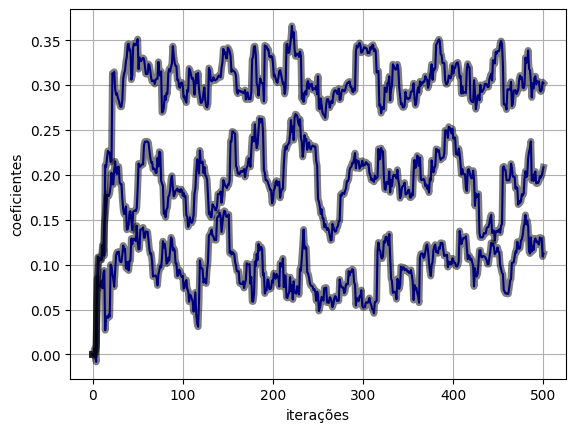

In [6]:
plot_ws(w_lms, w_lms)

## 2. Uso de tensores PyTorch

- Para manter a precisão numérica padrão do NumPy, vamos configurar o PyTorch para usar tensores do tipo `float64`:

In [7]:
torch.set_default_dtype(torch.float64)

- A forma de uso dos tensores PyTorch é bem semelhante à dos *arrays* NumPy. Na maioria dos casos, basta trocar a chamada `np.` por `torch.`:

In [8]:
x = torch.tensor(x)
wo = torch.tensor(wo)
d = torch.tensor(d)

In [9]:
def lms_torch(x, d, eta, M):
    N = len(x)
    
    # xM = np.zeros((M, 1))
    # wi = np.zeros((1, M))
    # y = np.zeros((N, 1))
    # e = np.zeros((N, 1))
    # w = np.zeros((N + 1, M))
    xM = torch.zeros((M, 1))
    wi = torch.zeros((1, M))
    y = torch.zeros((N, 1))
    e = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)
    
    for i in range(N):
        
        # xM = np.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        
        yi = wi @ xM
        ei = d[i] - yi
        wi = wi + eta/2 * 2 * ei * xM.T
        y[i] = yi
        e[i] = ei
        w[i + 1, :] = wi
    return y, e, w

In [10]:
(y_torch, e_torch, w_torch) = lms_torch(x, d, eta, M)

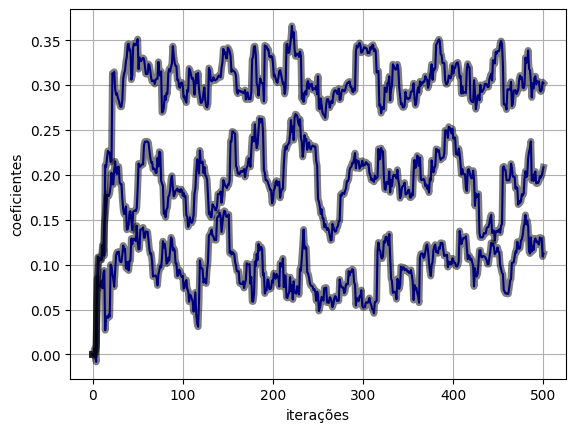

In [11]:
plot_ws(w_torch.numpy(), w_lms)

## 3. Uso do autograd

- Tensores que necessitam do cálculo do gradiente, devem ter o atributo `requires_grad=True`;
- Gradientes são calculados utilizando o método `.backward()` chamado no objeto que representa o nó em relação ao qual desejamos calcular os gradientes;
- É necessário tomar cuidado com operações para as quais não queremos calcular o gradiente. Nesses casos, utilizamos o bloco de contexto `with torch.no_grad():`;
- Note que é importante não sobrescrever o objeto `wi` para que os gradientes sejam computados corretamente (uso de `wi[:] = (...)`);
- A cada chamada de `.backward()`, os valores dos gradientes são acumulados nos atributos `.grad` de cada parâmetro do modelo;
  - Dessa forma, é necessário zerar os gradientes a cada iteração, usando o método `.grad.zero_()`.

In [12]:
def lms_torch_autograd(x, d, eta, M):
    N = len(x)
    xM = torch.zeros((M, 1))

    # wi = torch.zeros((1, M))
    wi = torch.zeros((1, M), requires_grad=True)

    y = torch.zeros((N, 1))
    e = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        yi = wi @ xM
        ei = d[i] - yi        

        # Novo
        mse = ei**2
        mse.backward()

        # wi = wi + eta/2 * 2 * ei * xM.T
        # y[i] = yi
        # e[i] = ei
        # w[i + 1, :] = wi
        with torch.no_grad():            
            wi[:] = wi[:] - eta/2 * wi.grad
            y[i] = yi
            e[i] = ei
            w[i + 1, :] = wi

        # Novo    
        wi.grad.zero_()
        
    return y, e, w

In [13]:
(y_torch_autograd, e_torch_autograd, w_torch_autograd) = lms_torch_autograd(x, d, eta, M)

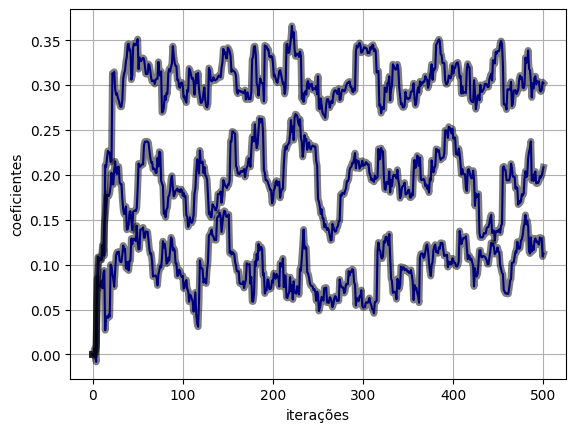

In [14]:
plot_ws(w_torch_autograd.numpy(), w_lms)

## 4. Blocos para função custo

- O PyTorch disponibiliza diversos blocos para a representação de funções custo: [https://pytorch.org/docs/stable/nn.html#loss-functions](https://pytorch.org/docs/stable/nn.html#loss-functions);
- Para o caso da função custo MSE, utilizamos o bloco `nn.MSELoss`.

In [15]:
def lms_torch_loss(x, d, eta, M):
    N = len(x)
    xM = torch.zeros((M, 1))
    wi = torch.zeros((1, M), requires_grad=True)
    y = torch.zeros((N, 1))
    
    #e = torch.zeros((N, 1))
    losses = torch.zeros((N, 1))

    w = torch.zeros(N + 1, M)

    # Novo
    loss_function = nn.MSELoss()
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        yi = wi @ xM

        #ei = d[i] - yi
        #mse = ei**2
        #mse.backward()
        loss = loss_function(yi.squeeze(), d[i].squeeze())
        loss.backward()
    
        with torch.no_grad():            
            wi[:] = wi[:] - eta/2 * wi.grad
            y[i] = yi
            losses[i] = loss
            w[i + 1, :] = wi
        wi.grad.zero_()
    return y, loss, w

In [16]:
(y_torch_loss, e_torch_loss, w_torch_loss) = lms_torch_loss(x, d, eta, M)

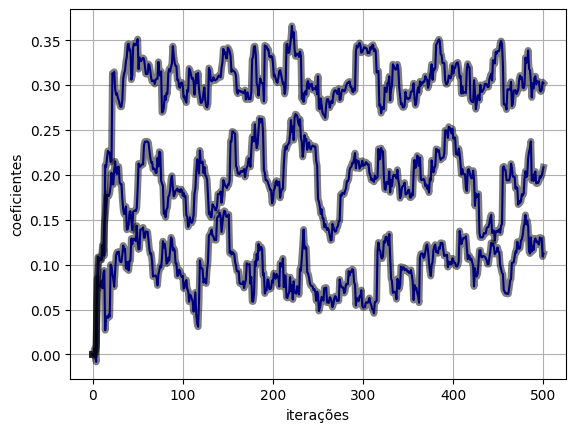

In [17]:
plot_ws(w_torch_loss.numpy(), w_lms)

## 5. Blocos para otimizadores

- O PyTorch disponibiliza diversos blocos para a representação de otimizadores: [https://pytorch.org/docs/stable/optim.html#algorithms](https://pytorch.org/docs/stable/optim.html#algorithms);
- Para o caso do otimizador com o algoritmo *backpropagation* tradicional, chamado de *Stochastic Gradient Descent*, utilizamos o bloco `nn.SGD`;
- A atualização dos pesos do otimizador é feita chamando o método `.step()`.


In [18]:
def lms_torch_optim(x, d, eta, M):
    N = len(x)
    xM = torch.zeros((M, 1))
    wi = torch.zeros((1, M), requires_grad=True)
    y = torch.zeros((N, 1))
    losses = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)

    loss_function = nn.MSELoss()

    # Novo
    optimizer = torch.optim.SGD([wi], lr=eta/2)
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        yi = wi @ xM
        loss = loss_function(yi.squeeze(), d[i].squeeze())
        loss.backward()

        # Novo
        optimizer.step()
    
        with torch.no_grad():            
            
            # wi[:] = wi[:] - eta/2 * wi.grad
            
            y[i] = yi
            losses[i] = loss
            w[i + 1, :] = wi
        wi.grad.zero_()
    return y, loss, w

In [19]:
(y_torch_optim, e_torch_optim, w_torch_optim) = lms_torch_optim(x, d, eta, M)

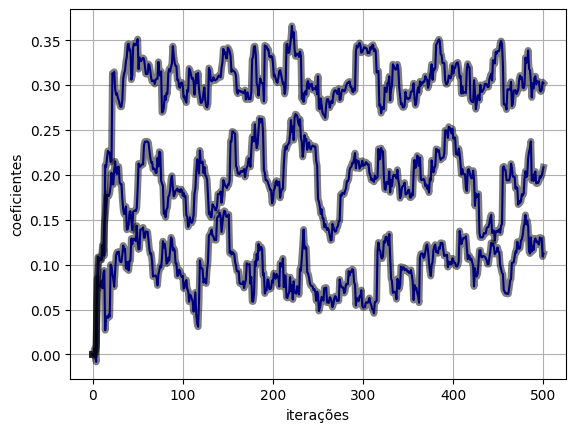

In [20]:
plot_ws(w_torch_optim.numpy(), w_lms)

## 6. Uso de objetos representando modelos PyTorch

- Os modelos PyTorch são construídos com a definição de classes que herdam de `nn.module`;
- No método `__init__()`, devem ser criados os elementos que compõem o modelo. Nesse caso, vamos utilizar apenas um objeto representando parâmetros genéricos;
- O método `forward()` define como é calculada a saída a partir da entrada, nesse caso chamada de `xM`;
- Após a criação da classe, instancia-se um objeto para representar o modelo;
  - A saída do modelo é calculada utilizando este objeto.
- Assim como feito anteriormente, é necessário zerar os gradientes do modelo a cada iteração;
  - É usual fazer isso no início do loop de treinamento.

In [21]:
# Novo
class LMS(nn.Module):
    def __init__(self):
        super().__init__()
        self.wi = nn.Parameter(torch.zeros((1, M), requires_grad=True))
        
    def forward(self, xM):
        output = self.wi @ xM
        return output

# Novo
model = LMS()

# def lms_torch_optim(x, d, eta, M):
def lms_torch_model(x, d, eta, M, model):

    N = len(x)
    xM = torch.zeros((M, 1))
    
    # wi = torch.zeros((1, M), requires_grad=True)
    
    y = torch.zeros((N, 1))
    losses = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)

    loss_function = nn.MSELoss()

    #optimizer = torch.optim.SGD([wi], lr=eta/2)
    optimizer = torch.optim.SGD(model.parameters(), lr=eta/2)
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))

        # yi = wi @ xM
        model.zero_grad()
        yi = model(xM)

        loss = loss_function(yi.squeeze(), d[i].squeeze())
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():            
            y[i] = yi
            losses[i] = loss
            
            # w[i + 1, :] = wi
            w[i + 1, :] = model.wi.clone()

        # wi.grad.zero_()        
    
    return y, loss, w

In [22]:
(y_torch_model, e_torch_model, w_torch_model) = lms_torch_model(x, d, eta, M, model)

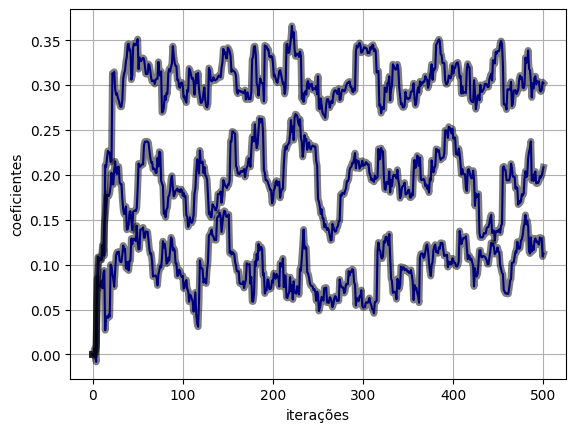

In [23]:
plot_ws(w_torch_model.numpy(), w_lms)

## 7. Uso de blocos PyTorch para a composição de modelos

- No último exemplo, construímos um modelo PyTorch baseado em um conjunto de parâmetros configurados com `nn.Parameter`.
  - No entanto, o PyTorch conta com inúmeros blocos para a composição de modelos como blocos lineares e funções de ativação para a composição de camadas de redes MLP;
  - Ref.: [https://pytorch.org/docs/stable/nn.html](https://pytorch.org/docs/stable/nn.html).
- No caso do LMS, podemos utilizar o bloco `nn.Linear`.

In [24]:
# class LMS(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.wi = nn.Parameter(torch.zeros((1, M), requires_grad=True))
        
#     def forward(self, xM):
#         output = self.wi @ xM
#         return output

class LMS(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(M, 1, bias=False)        
        
    def forward(self, x):
        output = self.l1(x.squeeze())
        return output

model = LMS()

def lms_torch_model_2(x, d, eta, M, model):
    N = len(x)
    xM = torch.zeros((M, 1))
    y = torch.zeros((N, 1))
    losses = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)

    loss_function = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=eta/2)
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        model.zero_grad()
        yi = model(xM)
        loss = loss_function(yi.squeeze(), d[i].squeeze())
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():            
            y[i] = yi
            losses[i] = loss

            # w[i + 1, :] = model.wi.clone()
            w[i + 1, :] = model.l1.weight.clone()

    return y, loss, w

In [25]:
(y_torch_model_2, e_torch_model_2, w_torch_model_2) = lms_torch_model_2(x, d, eta, M, model)

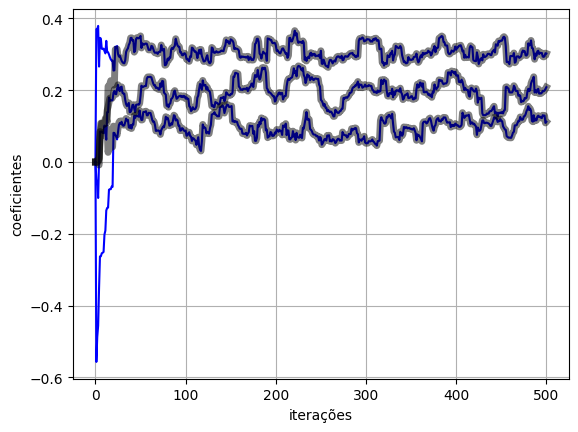

In [26]:
plot_ws(w_torch_model_2.numpy(), w_lms)

- As curvas de evolução dos pesos não coincidem com as anteriores, neste caso.
  - Isso ocorre por conta da inicialialização dos pesos utilizada pelo bloco `nn.Linear`que não são inicializados com zeros, conforme descrito na [documentação](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html).
- Para obter o mesmo comportamento, é necessário inicializar os pesos com zeros:

In [27]:
class LMS(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(M, 1, bias=False)

    def forward(self, x):
        output = self.l1(x.squeeze())
        return output

# Novo
def weights_init(m):
    classname = m.__class__.__name__    
    if classname.find('Linear') != -1:
        if m.weight is not None:
            #torch.nn.init.xavier_normal_(m.weight)
            torch.nn.init.zeros_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

model = LMS()

# Novo
model.apply(weights_init)


def lms_torch_model_3(x, d, eta, M, model):
    N = len(x)
    xM = torch.zeros((M, 1))
    y = torch.zeros((N, 1))
    losses = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)

    loss_function = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=eta/2)
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        model.zero_grad()
        yi = model(xM)
        loss = loss_function(yi.squeeze(), d[i].squeeze())
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():            
            y[i] = yi
            losses[i] = loss            
            w[i + 1, :] = model.l1.weight.clone()
    return y, loss, w

In [28]:
(y_torch_model_3, e_torch_model_3, w_torch_model_3) = lms_torch_model_3(x, d, eta, M, model)

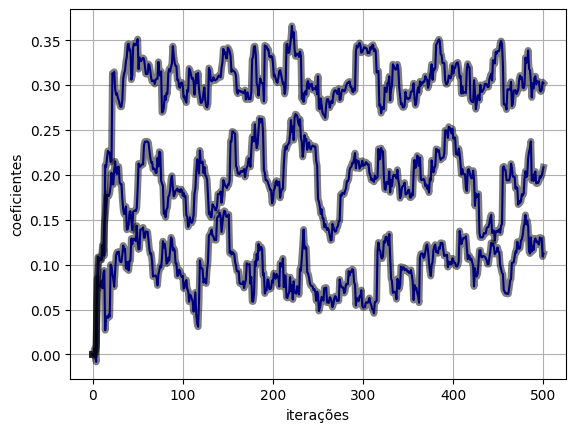

In [29]:
plot_ws(w_torch_model_3.numpy(), w_lms)